In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def build_rotation_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert pitcher-level simulation output into one row per rotation.
    
    Expected columns in df:
        sim_id, bucket, total_payroll, WAR, salary, is_ace, is_good
        
    Returns:
        rotation_summary with one row per sim_id
    """
    rotation_summary = (
        df.groupby(["sim_id", "bucket", "total_payroll"], as_index=False)
        .agg(
            total_war=("WAR", "sum"),
            avg_war=("WAR", "mean"),
            std_war=("WAR", "std"),
            max_war=("WAR", "max"),
            min_war=("WAR", "min"),
            total_salary=("salary", "sum"),
            avg_salary=("salary", "mean"),
            std_salary=("salary", "std"),
            max_salary=("salary", "max"),
            min_salary=("salary", "min"),
            num_aces=("is_ace", "sum"),
            num_good=("is_good", "sum"),
            champ_prob=("champ_prob", "first") 
        )
    )

    # For cases where std is NaN (shouldn't happen with 5 pitchers, but safe anyway)
    rotation_summary["std_war"] = rotation_summary["std_war"].fillna(0)
    rotation_summary["std_salary"] = rotation_summary["std_salary"].fillna(0)

    return rotation_summary

def classify_archetype(row: pd.Series,
                       balanced_std_threshold: float = 1.0,
                       offense_heavy_threshold: float | None = None) -> str:
    """
    Rule-based archetype classification.
    
    Archetypes:
        - multi_ace
        - single_ace
        - balanced
        - high_variance
        - offense_heavy (optional, only if offense_war is available)
    """
    # Optional offense-heavy classification
    if offense_heavy_threshold is not None and "offense_war" in row.index:
        if row["offense_war"] >= offense_heavy_threshold and row["num_aces"] == 0:
            return "offense_heavy"

    if row["num_aces"] >= 2:
        return "multi_ace"
    elif row["num_aces"] == 1:
        return "single_ace"
    elif row["std_war"] <= balanced_std_threshold:
        return "balanced"
    else:
        return "high_variance"
    
def add_archetypes(rotation_summary: pd.DataFrame,
                   balanced_std_threshold: float = 1.0,
                   offense_heavy_threshold: float | None = None) -> pd.DataFrame:
    """
    Add an 'archetype' column to rotation_summary.
    """
    out = rotation_summary.copy()
    out["archetype"] = out.apply(
        classify_archetype,
        axis=1,
        balanced_std_threshold=balanced_std_threshold,
        offense_heavy_threshold=offense_heavy_threshold
    )
    return out

def summarize_performance(rotation_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize average performance metrics overall
    
    If champ_prob exists, include it in the summary.
    """
    agg_dict = {
        "total_war": ["mean", "std"],
        "std_war": ["mean"],
        "max_war": ["mean"],
        "num_aces": ["mean"],
        "num_good": ["mean"],
        "total_salary": ["mean"]
    }

    if "champ_prob" in rotation_summary.columns:
        agg_dict["champ_prob"] = ["mean"]

    summary = rotation_summary.agg(agg_dict)
    summary = summary.reset_index()

    return summary



def summarize_performance_by_archetype(rotation_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize average performance metrics by archetype.
    
    If champ_prob exists, include it in the summary.
    """
    agg_dict = {
        "total_war": ["mean", "median"],
        "avg_war": ["mean"],
        "std_war": ["mean"],
        "max_war": ["mean"],
        "num_aces": ["mean"],
        "num_good": ["mean"],
        "total_salary": ["mean"]
    }

    if "champ_prob" in rotation_summary.columns:
        agg_dict["champ_prob"] = ["mean", "median", "std"]

    summary = rotation_summary.groupby("archetype").agg(agg_dict)
    summary.columns = ["_".join(col).strip() for col in summary.columns]
    summary = summary.reset_index()

    return summary

def summarize_performance_by_budget(rotation_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize average performance metrics by budget bucket.
    
    If champ_prob exists, include it in the summary.
    """
    agg_dict = {
        "total_war": ["mean", "std"],
        "std_war": ["mean"],
        "max_war": ["mean"],
        "num_aces": ["mean"],
        "num_good": ["mean"],
        "total_salary": ["mean"]
    }

    if "champ_prob" in rotation_summary.columns:
        agg_dict["champ_prob"] = ["mean"]

    summary = rotation_summary.groupby("bucket").agg(agg_dict)
    summary.columns = ["_".join(col).strip() for col in summary.columns]
    summary = summary.reset_index()

    return summary



# =========================================================
# 4) Conditional analysis: performance by budget + archetype
# =========================================================

def summarize_performance_by_bucket_and_archetype(rotation_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize archetype usage and performance within each budget bucket.
    """
    grouped = (
        rotation_summary
        .groupby(["bucket", "archetype"], as_index=False)
        .agg(
            n_rotations=("sim_id", "count"),
            avg_total_war=("total_war", "mean"),
            avg_std_war=("std_war", "mean"),
            avg_num_aces=("num_aces", "mean"),
            avg_total_salary=("total_salary", "mean")
        )
    )

    if "champ_prob" in rotation_summary.columns:
        champ = (
            rotation_summary
            .groupby(["bucket", "archetype"], as_index=False)
            .agg(avg_champ_prob=("champ_prob", "mean"))
        )
        grouped = grouped.merge(champ, on=["bucket", "archetype"], how="left")

    # Add within-bucket percentage
    grouped["pct_within_bucket"] = (
        grouped["n_rotations"] /
        grouped.groupby("bucket")["n_rotations"].transform("sum")
    )

    return grouped


# =========================================================
# 6) Visualization
# =========================================================

def plot_archetype_distribution_by_bucket(rotation_summary: pd.DataFrame,
                                          save_path: str | None = None) -> None:
    """
    Stacked bar chart of archetype frequencies within each budget bucket.
    """
    counts = (
        rotation_summary.groupby(["bucket", "archetype"])
        .size()
        .unstack(fill_value=0)
    )

    pct = counts.div(counts.sum(axis=1), axis=0)

    ax = pct.plot(kind="bar", stacked=True, figsize=(10, 6))
    ax.set_xlabel("Budget Bucket")
    ax.set_ylabel("Share of Rotations")
    ax.legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_champ_prob_by_archetype(rotation_summary: pd.DataFrame,
                                 save_path: str | None = None) -> None:
    """
    Bar chart of average championship probability by archetype.
    """
    if "champ_prob" not in rotation_summary.columns:
        raise ValueError("rotation_summary must contain a 'champ_prob' column.")

    data = (
        rotation_summary.groupby("archetype", as_index=False)
        .agg(avg_champ_prob=("champ_prob", "mean"))
        .sort_values("avg_champ_prob", ascending=False)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(data["archetype"], data["avg_champ_prob"])
    plt.xlabel("Archetype")
    plt.ylabel("Average Championship Probability")
    plt.xticks(rotation=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_std_war_vs_champ_prob(rotation_summary: pd.DataFrame,
                               save_path: str | None = None) -> None:
    """
    Scatter plot of WAR dispersion vs championship probability.
    """
    if "champ_prob" not in rotation_summary.columns:
        raise ValueError("rotation_summary must contain a 'champ_prob' column.")

    plt.figure(figsize=(8, 5))
    plt.scatter(rotation_summary["std_war"], rotation_summary["champ_prob"], alpha=0.6)
    plt.xlabel("Within-Rotation WAR Std Dev (Dispersion)")
    plt.ylabel("Championship Probability")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_num_aces_vs_champ_prob(rotation_summary: pd.DataFrame,
                                save_path: str | None = None) -> None:
    """
    Bar chart of average championship probability by number of aces.
    """
    if "champ_prob" not in rotation_summary.columns:
        raise ValueError("rotation_summary must contain a 'champ_prob' column.")

    data = (
        rotation_summary.groupby("num_aces", as_index=False)
        .agg(avg_champ_prob=("champ_prob", "mean"))
        .sort_values("num_aces")
    )

    plt.figure(figsize=(8, 5))
    plt.bar(data["num_aces"].astype(str), data["avg_champ_prob"])
    plt.xlabel("Number of Aces")
    plt.ylabel("Average Championship Probability")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =========================================================
# 8) Clustering-based archetypes
# =========================================================

def add_cluster_archetypes(rotation_summary: pd.DataFrame,
                           n_clusters: int = 4,
                           random_state: int = 42) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Use KMeans to create data-driven archetypes.
    
    Features used:
        total_war, max_war, std_war, num_aces, total_salary
        
    Returns:
        rotation_summary_with_clusters, cluster_centers_df
    """
    feature_cols = ["total_war", "max_war", "std_war", "num_aces", "total_salary"]
    out = rotation_summary.copy()

    X = out[feature_cols].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    out["cluster"] = kmeans.fit_predict(X_scaled)

    # Convert cluster centers back to original scale for interpretation
    centers_scaled = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)

    cluster_centers_df = pd.DataFrame(centers_original, columns=feature_cols)
    cluster_centers_df["cluster"] = range(n_clusters)

    return out, cluster_centers_df


def summarize_clusters(rotation_summary: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize cluster-based archetypes.
    """
    if "cluster" not in rotation_summary.columns:
        raise ValueError("rotation_summary must contain a 'cluster' column.")

    agg_dict = {
        "sim_id": "count",
        "total_war": "mean",
        "max_war": "mean",
        "std_war": "mean",
        "num_aces": "mean",
        "total_salary": "mean"
    }

    if "champ_prob" in rotation_summary.columns:
        agg_dict["champ_prob"] = "mean"

    summary = (
        rotation_summary.groupby("cluster", as_index=False)
        .agg(**{
            "n_rotations": ("sim_id", "count"),
            "avg_total_war": ("total_war", "mean"),
            "avg_max_war": ("max_war", "mean"),
            "avg_std_war": ("std_war", "mean"),
            "avg_num_aces": ("num_aces", "mean"),
            "avg_total_salary": ("total_salary", "mean"),
            **({"avg_champ_prob": ("champ_prob", "mean")} if "champ_prob" in rotation_summary.columns else {})
        })
    )

    return summary


In [24]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


def evaluate_kmeans_clusters(
    rotation_summary: pd.DataFrame,
    feature_cols: list[str] | None = None,
    k_range: range = range(2, 9),
    random_state: int = 42,
    n_init: int = 10,
    plot: bool = True
) -> pd.DataFrame:
    """
    Evaluate candidate numbers of KMeans clusters using several metrics.

    Parameters
    ----------
    rotation_summary : pd.DataFrame
        One row per rotation.
    feature_cols : list[str] | None
        Features to use for clustering. If None, defaults to:
        ["total_war", "max_war", "std_war", "num_aces", "total_salary"]
    k_range : range
        Candidate k values to test.
    random_state : int
        Random seed for reproducibility.
    n_init : int
        KMeans n_init parameter.
    plot : bool
        If True, show diagnostic plots.

    Returns
    -------
    pd.DataFrame
        DataFrame with clustering metrics for each k:
        k, inertia, silhouette, calinski_harabasz, davies_bouldin
    """
    if feature_cols is None:
        feature_cols = ["total_war", "max_war", "std_war", "num_aces", "total_salary"]

    X = rotation_summary[feature_cols].copy()

    if X.isnull().any().any():
        raise ValueError("Selected feature columns contain missing values.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = []

    for k in k_range:
        if k < 2:
            raise ValueError("k must be at least 2 for clustering evaluation.")
        if k >= len(X_scaled):
            # Cannot have more clusters than observations in any meaningful way
            continue

        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = kmeans.fit_predict(X_scaled)

        row = {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        }
        results.append(row)

    results_df = pd.DataFrame(results)

    if plot and not results_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # Elbow plot
        axes[0, 0].plot(results_df["k"], results_df["inertia"], marker="o")
        axes[0, 0].set_title("Elbow Plot (Inertia)")
        axes[0, 0].set_xlabel("Number of Clusters (k)")
        axes[0, 0].set_ylabel("Inertia")

        # Silhouette
        axes[0, 1].plot(results_df["k"], results_df["silhouette"], marker="o")
        axes[0, 1].set_title("Silhouette Score")
        axes[0, 1].set_xlabel("Number of Clusters (k)")
        axes[0, 1].set_ylabel("Silhouette")

        # Davies-Bouldin
        axes[1, 0].plot(results_df["k"], results_df["davies_bouldin"], marker="o")
        axes[1, 0].set_title("Davies-Bouldin Score")
        axes[1, 0].set_xlabel("Number of Clusters (k)")
        axes[1, 0].set_ylabel("Score (lower is better)")
        axes[1,1].axis("off")  # Hide unused subplot

        plt.tight_layout()
        plt.show()

    return results_df


def recommend_best_k(results_df: pd.DataFrame) -> int:
    """
    Recommend a best k from the evaluation table.

    Heuristic:
    - maximize silhouette
    - among close candidates, prefer lower Davies-Bouldin
    - among close candidates, prefer higher Calinski-Harabasz

    Returns
    -------
    int
        Recommended number of clusters.
    """
    if results_df.empty:
        raise ValueError("results_df is empty.")

    df = results_df.copy()

    # Rank metrics
    df["silhouette_rank"] = df["silhouette"].rank(ascending=False, method="min")
    df["davies_rank"] = df["davies_bouldin"].rank(ascending=True, method="min")

    # Simple combined rank score
    df["total_rank"] = df["silhouette_rank"] + df["davies_rank"]

    best_row = df.sort_values(
        ["total_rank", "silhouette", "davies_bouldin", ],
        ascending=[True, False, False]
    ).iloc[0]

    return int(best_row["k"])

In [25]:
simulation_summary = pd.read_csv("mc_outputs/simulation_summary.csv")
rotation_pitchers = pd.read_csv("mc_outputs/rotation_pitchers.csv")
rotation_pitchers.drop(columns = "sim_id")
# create a merge key based on row order
simulation_summary = simulation_summary.reset_index(drop=True)
simulation_summary["sim_id"] = simulation_summary.index

rotation_pitchers = rotation_pitchers.reset_index(drop=True)
rotation_pitchers["sim_id"] = rotation_pitchers.index // 5

# merge champ_prob onto each pitcher row
rotation_pitchers = rotation_pitchers.merge(
    simulation_summary[["sim_id", "champ_prob"]],
    on="sim_id",
    how="left"
)

# optional: drop helper column
# rotation_pitchers = rotation_pitchers.drop(columns="sim_id")
print(rotation_pitchers["bucket"].value_counts())
rotation_pitchers

bucket
low_budget     1590
mid_budget     1590
high_budget    1590
Name: count, dtype: int64


,sim_id,bucket,total_payroll,rotation_slot,name_common,year_ID,team_ID,WAR,salary,mlb_ID,player_ID,GS,is_ace,is_good,champ_prob
0,0,low_budget,120000000,1,Logan Webb,2023,SFG,5.61,4600000.0,657277.0,webblo01,33,1,1,0.156
1,0,low_budget,120000000,2,Chris Sale,2024,ATL,6.20,16000000.0,519242.0,salech01,29,1,1,0.156
2,0,low_budget,120000000,3,Jesús Luzardo,2023,MIA,4.72,2450000.0,666200.0,luzarje01,32,0,1,0.156
3,0,low_budget,120000000,4,Lance Lynn,2019,TEX,7.70,9333333.0,458681.0,lynnla01,33,1,1,0.156
4,0,low_budget,120000000,5,Cristopher Sánchez,2025,PHI,7.97,2000000.0,650911.0,sanchcr01,32,1,1,0.156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,953,high_budget,275000000,1,Tarik Skubal,2024,DET,6.42,2650000.0,669373.0,skubata01,31,1,1,0.314
4766,953,high_budget,275000000,2,Eduardo Rodríguez,2019,BOS,5.48,4300000.0,593958.0,rodried05,34,1,1,0.314
4767,953,high_budget,275000000,3,Aaron Nola,2018,PHI,9.69,573000.0,605400.0,nolaaa01,33,1,1,0.314
4768,953,high_budget,275000000,4,Jacob deGrom,2019,NYM,7.18,9000000.0,594798.0,degroja01,32,1,1,0.314


In [39]:
rotation_summary = build_rotation_summary(rotation_pitchers)
rotation_summary = add_archetypes(rotation_summary, balanced_std_threshold=rotation_summary["std_war"].quantile(0.33))
print(rotation_summary["bucket"].value_counts())
rotation_summary


bucket
low_budget     318
mid_budget     318
high_budget    318
Name: count, dtype: int64


,sim_id,bucket,total_payroll,total_war,avg_war,std_war,max_war,min_war,total_salary,avg_salary,std_salary,max_salary,min_salary,num_aces,num_good,champ_prob,archetype
0,0,low_budget,120000000,32.20,6.440,1.381430,7.97,4.72,34383333.0,6876666.6,5.870070e+06,16000000.0,2000000.0,4,5,0.156,multi_ace
1,1,low_budget,120000000,21.29,4.258,2.030904,6.87,1.27,28290000.0,5658000.0,3.247048e+06,8000000.0,590000.0,1,4,0.100,single_ace
2,2,low_budget,120000000,38.08,7.616,2.055074,9.69,5.48,24073000.0,4814600.0,3.004849e+06,8000000.0,573000.0,5,5,0.225,multi_ace
3,3,mid_budget,175000000,35.89,7.178,1.066663,7.97,5.44,42049333.0,8409866.6,8.545797e+06,22143000.0,573000.0,4,5,0.226,multi_ace
4,4,mid_budget,175000000,4.62,0.924,0.874088,2.04,-0.11,41129960.0,8225992.0,8.257532e+06,21000000.0,545000.0,0,1,0.020,balanced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,949,high_budget,275000000,32.85,6.570,1.440989,7.70,4.35,74173333.0,14834666.6,1.432596e+07,36000000.0,740000.0,4,5,0.266,multi_ace
950,950,high_budget,275000000,33.86,6.772,2.068132,9.44,3.96,36925000.0,7385000.0,3.779699e+06,12500000.0,2000000.0,4,5,0.306,multi_ace
951,951,high_budget,275000000,32.15,6.430,2.043367,7.99,3.00,26990000.0,5398000.0,6.071760e+06,16000000.0,550000.0,4,5,0.301,multi_ace
952,952,high_budget,275000000,39.73,7.946,1.051228,9.69,7.11,7431200.0,1486240.0,1.410706e+06,3750000.0,550000.0,5,5,0.366,multi_ace


In [27]:
# 3) summarize performance across archetypes
archetype_perf = summarize_performance_by_archetype(rotation_summary)
print("\nPerformance by archetype:")
archetype_perf


Performance by archetype:


,archetype,total_war_mean,total_war_median,avg_war_mean,std_war_mean,max_war_mean,num_aces_mean,num_good_mean,total_salary_mean,champ_prob_mean,champ_prob_median,champ_prob_std
0,balanced,13.442000,13.150,2.688400,1.117628,4.071600,0.000000,3.720000,3.339440e+07,0.061200,0.061,0.034018
1,high_variance,7.589375,8.200,1.517875,1.866818,3.896250,0.000000,2.437500,3.739545e+07,0.028938,0.021,0.022407
2,multi_ace,33.222774,33.595,6.644555,1.728538,8.781515,3.692308,4.980186,2.954429e+07,0.227599,0.217,0.063061
3,single_ace,21.652000,22.750,4.330400,1.962502,7.380909,1.000000,4.454545,3.034238e+07,0.119109,0.117,0.039149


In [62]:
budget_perf = summarize_performance_by_budget(rotation_summary)
print("\nPerformance by budget:")
budget_perf


Performance by budget:


,bucket,total_war_mean,total_war_std,std_war_mean,max_war_mean,num_aces_mean,num_good_mean,total_salary_mean,champ_prob_mean
0,high_budget,33.136069,5.148545,1.697383,8.746289,3.663522,4.943396,3.053294e+07,0.286918
1,low_budget,30.381321,7.213937,1.787952,8.327956,3.110063,4.833333,2.705126e+07,0.159019
2,mid_budget,31.304874,6.889039,1.699674,8.411981,3.361635,4.845912,3.188440e+07,0.195019


In [63]:
perf = summarize_performance(rotation_summary)
print("\nPerformance by overall:")
perf


Performance by overall:


,index,total_war,std_war,max_war,num_aces,num_good,total_salary,champ_prob
0,mean,31.607421,1.728337,8.495409,3.378407,4.874214,2.982287e+07,0.213652
1,std,6.574663,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# 4) summarize by budget and archetype
bucket_archetype_perf = summarize_performance_by_bucket_and_archetype(rotation_summary)
print("\nPerformance by bucket and archetype:")
bucket_archetype_perf


Performance by bucket and archetype:


,bucket,archetype,n_rotations,avg_total_war,avg_std_war,avg_num_aces,avg_total_salary,avg_champ_prob,pct_within_bucket
0,high_budget,balanced,3,15.453333,1.264974,0.000000,5.766928e+07,0.094333,0.009434
1,high_budget,high_variance,1,2.210000,1.773477,0.000000,3.083167e+07,0.027000,0.003145
2,high_budget,multi_ace,304,33.816414,1.692143,3.799342,3.011195e+07,0.293806,0.955975
3,high_budget,single_ace,10,20.851000,1.978809,1.000000,3.516033e+07,0.161300,0.031447
4,low_budget,balanced,12,14.878333,1.041525,0.000000,2.572097e+07,0.064833,0.037736
5,low_budget,high_variance,8,6.812500,2.075053,0.000000,2.790240e+07,0.021250,0.025157
6,low_budget,multi_ace,271,32.662657,1.801552,3.549815,2.689295e+07,0.173439,0.852201
7,low_budget,single_ace,27,21.357037,1.898125,1.000000,2.897921e+07,0.096963,0.084906
8,mid_budget,balanced,10,11.115000,1.164748,0.000000,3.532005e+07,0.046900,0.031447
9,mid_budget,high_variance,7,9.245714,1.642170,0.000000,4.918233e+07,0.038000,0.022013


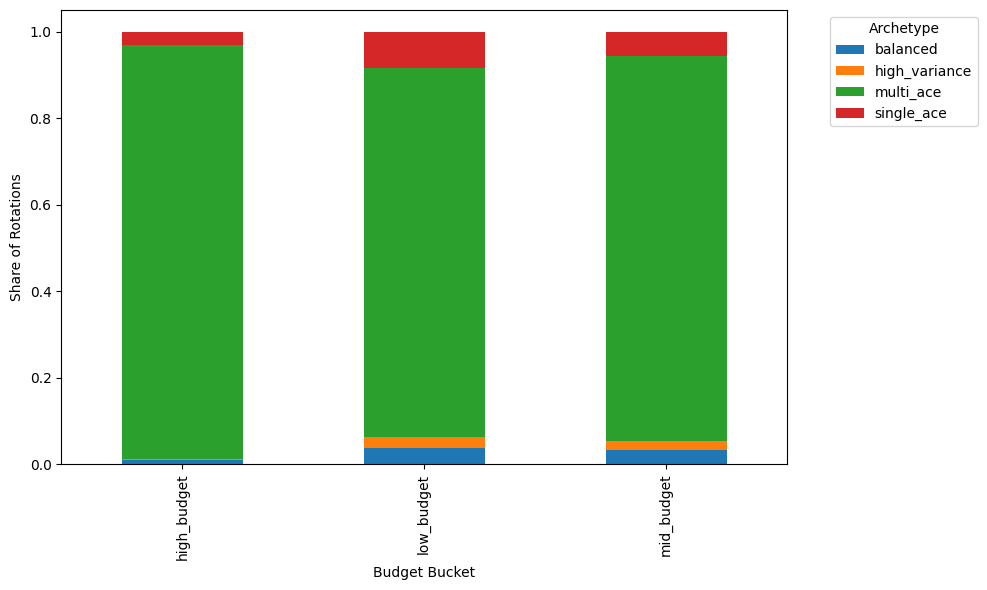

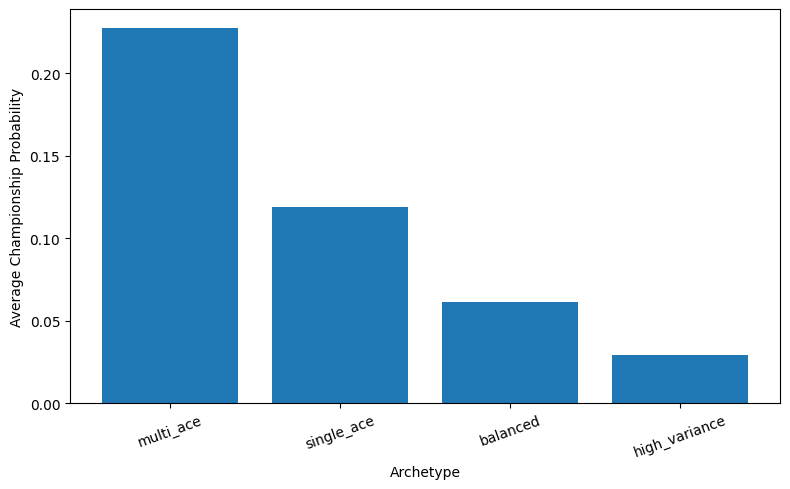

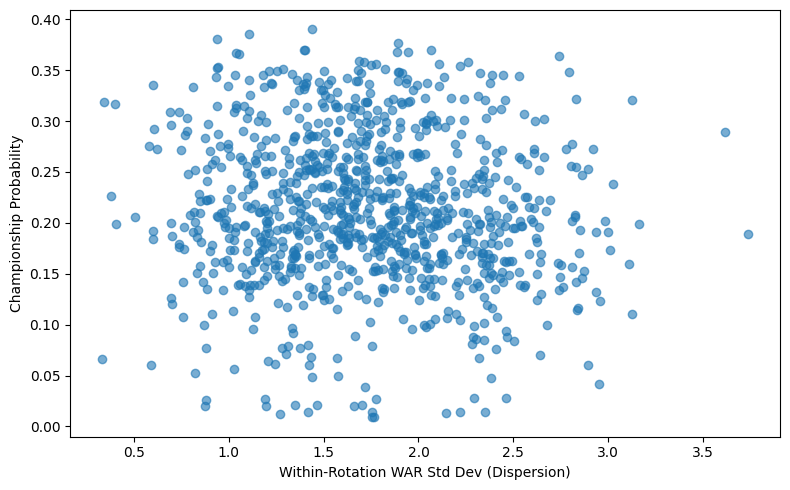

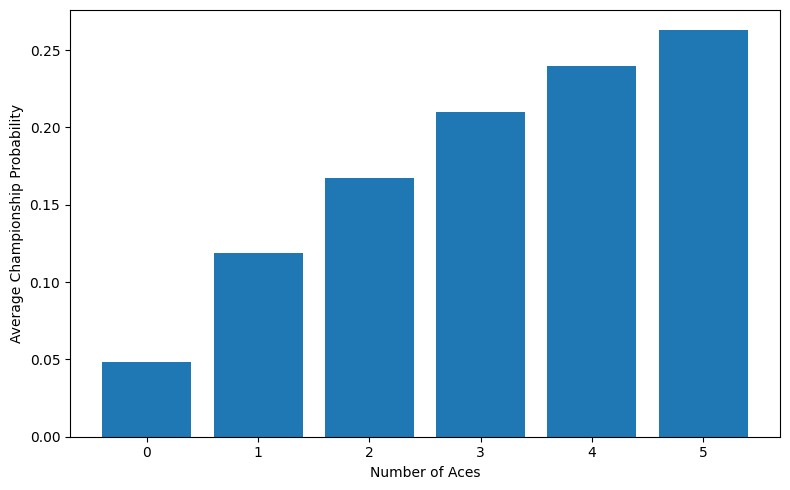

In [70]:
# 6) visualizations
plot_archetype_distribution_by_bucket(rotation_summary)

if "champ_prob" in rotation_summary.columns:
    plot_champ_prob_by_archetype(rotation_summary)
    plot_std_war_vs_champ_prob(rotation_summary)
    plot_num_aces_vs_champ_prob(rotation_summary)


In [30]:
# 8) clustering-based archetypes
rotation_summary_clustered, cluster_centers = add_cluster_archetypes(rotation_summary, n_clusters=4)
cluster_summary = summarize_clusters(rotation_summary_clustered)

print("\nCluster centers:")
print(cluster_centers)

print("\nCluster summary:")
print(cluster_summary)


Cluster centers:
   total_war   max_war   std_war  num_aces  total_salary  cluster
0  35.599669  8.666416  1.260064  4.493976  3.415391e+07        0
1  33.777456  9.531842  2.169839  3.476608  2.548938e+07        1
2  11.463182  4.158182  1.440211  0.068182  3.479460e+07        2
3  26.602203  7.561525  1.801008  2.283898  2.908300e+07        3

Cluster summary:
   cluster  n_rotations  avg_total_war  avg_max_war  avg_std_war  \
0        0          332      35.599669     8.666416     1.260064   
1        1          342      33.777456     9.531842     2.169839   
2        2           44      11.463182     4.158182     1.440211   
3        3          236      26.602203     7.561525     1.801008   

   avg_num_aces  avg_total_salary  avg_champ_prob  
0      4.493976      3.415391e+07        0.243931  
1      3.476608      2.548938e+07        0.236149  
2      0.068182      3.479460e+07        0.051545  
3      2.283898      2.908300e+07        0.168678  


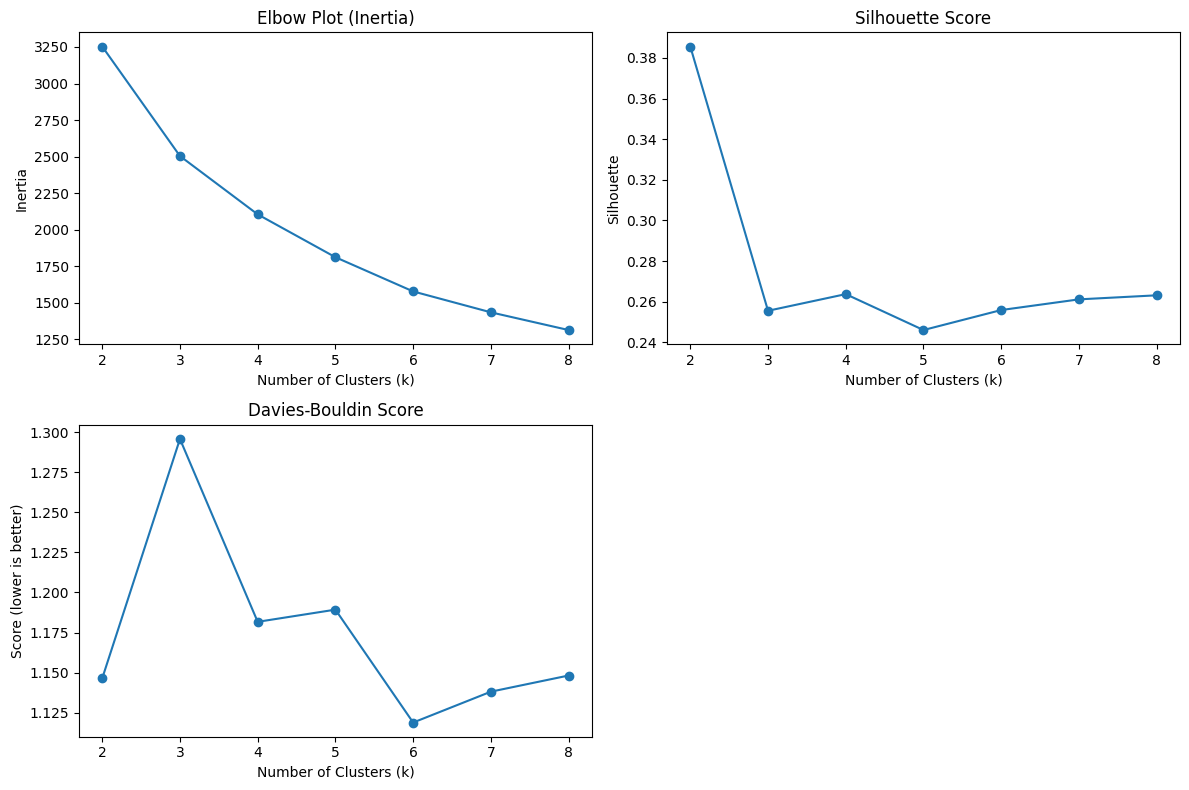

   k      inertia  silhouette  davies_bouldin
0  2  3253.319689    0.385600        1.146450
1  3  2504.182720    0.255576        1.295675
2  4  2105.185480    0.263763        1.181697
3  5  1812.125079    0.246090        1.189297
4  6  1578.119708    0.255931        1.118908
5  7  1435.086507    0.261185        1.138155
6  8  1313.970113    0.263179        1.148226
Recommended k: 2


In [31]:
# How many clusters to use
cluster_eval = evaluate_kmeans_clusters(
    rotation_summary,
    feature_cols=["total_war", "max_war", "std_war", "num_aces", "total_salary"],
    k_range=range(2, 9),
    plot=True
)

print(cluster_eval)

best_k = recommend_best_k(cluster_eval)
print("Recommended k:", best_k)

Cluster 0: Weak rotations
Cluster 1: Elite/Balanced (high-end depth)
Cluster 2: Top-Heavy
Cluster 3: Mid-Tier Balanced

Takeaway: Clusters 1 and 2 have similar avg champ prob --> similar performance, multiple ways to go about it, BUT Cluster 2 has lower cost, so Star-heavy constructions may be more efficient under budget constraints.

In [71]:
def cluster_distribution_by_bucket(df: pd.DataFrame):
    """
    Returns:
        counts: raw number of rotations in each (bucket, cluster)
        pct: percentage share of each cluster within each bucket
    """
    counts = (
        df.groupby(["bucket", "cluster"])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

    pct = counts.div(counts.sum(axis=1), axis=0)

    return counts, pct


# =========================================================
# 2) PERFORMANCE OF EACH CLUSTER WITHIN EACH BUCKET
# =========================================================

def performance_by_bucket_and_cluster(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns one row per (bucket, cluster) with average metrics.
    Requires:
        bucket, cluster, sim_id, total_war, std_war, num_aces,
        total_salary, champ_prob
    """
    summary = (
        df.groupby(["bucket", "cluster"], as_index=False)
        .agg(
            n_rotations=("sim_id", "count"),
            avg_total_war=("total_war", "mean"),
            avg_std_war=("std_war", "mean"),
            avg_num_aces=("num_aces", "mean"),
            avg_total_salary=("total_salary", "mean"),
            avg_champ_prob=("champ_prob", "mean")
        )
        .sort_values(["bucket", "avg_champ_prob"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return summary


# =========================================================
# 3) BEST-PERFORMING CLUSTER IN EACH BUCKET
# =========================================================

def dominant_cluster_by_bucket(perf_df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes output of performance_by_bucket_and_cluster()
    and returns the highest avg_champ_prob cluster in each bucket.
    """
    dominant = perf_df.loc[
        perf_df.groupby("bucket")["avg_champ_prob"].idxmax()
    ].sort_values("bucket").reset_index(drop=True)

    return dominant


# =========================================================
# 4) MOST COMMON CLUSTER IN EACH BUCKET
# =========================================================

def most_common_cluster_by_bucket(counts_df: pd.DataFrame) -> pd.DataFrame:
    """
    Takes counts table from cluster_distribution_by_bucket()
    and returns the most frequent cluster in each bucket.
    """
    out = pd.DataFrame({
        "bucket": counts_df.index,
        "most_common_cluster": counts_df.idxmax(axis=1).values,
        "count": counts_df.max(axis=1).values
    }).reset_index(drop=True)

    return out


# =========================================================
# 5) PLOT: CLUSTER DISTRIBUTION WITHIN EACH BUCKET
# =========================================================

def plot_cluster_distribution_by_bucket(pct_df: pd.DataFrame, save_path: str | None = None):
    """
    Stacked bar chart of cluster shares within each bucket.
    """
    ax = pct_df.plot(kind="bar", stacked=True, figsize=(10, 6))
    ax.set_xlabel("Budget Bucket")
    ax.set_ylabel("Share of Rotations")
    ax.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# =========================================================
# 6) PLOT: AVG CHAMP PROB BY CLUSTER WITHIN EACH BUCKET
# =========================================================

def plot_champ_prob_by_bucket_and_cluster(perf_df: pd.DataFrame, save_dir: str | None = None):
    """
    Creates a 2x2 figure with one bar chart per bucket (3 total, 1 empty),
    using:
      - fixed bucket ordering
      - standardized y-axis across plots
      - consistent cluster colors across buckets
    """
    bucket_order = ["low_budget", "mid_budget", "high_budget"]
    buckets = [b for b in bucket_order if b in perf_df["bucket"].unique()]

    # Global y-axis scale
    y_max = perf_df["avg_champ_prob"].max()
    y_min = 0
    y_buffer = 0.05 * y_max if y_max > 0 else 0.01
    y_upper = y_max + y_buffer

    # Consistent colors by cluster
    all_clusters = sorted(perf_df["cluster"].unique())
    cmap = plt.get_cmap("tab10")
    cluster_color_map = {
        cluster: cmap(i % 10) for i, cluster in enumerate(all_clusters)
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, bucket in enumerate(buckets):
        ax = axes[i]
        subset = perf_df[perf_df["bucket"] == bucket].sort_values("cluster")

        bar_colors = [cluster_color_map[c] for c in subset["cluster"]]
        bars = ax.bar(
            subset["cluster"].astype(str),
            subset["avg_champ_prob"],
            color=bar_colors
        )

        # Salary labels inside bars
        for bar, salary in zip(bars, subset["avg_total_salary"]):
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height / 2,
                f"${salary/1e6:.1f}M",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )

        ax.set_title(bucket.replace("_", " ").title())
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Avg Champ Prob")
        ax.set_ylim(y_min, y_upper)

    # Remove unused 4th subplot
    for j in range(len(buckets), 4):
        fig.delaxes(axes[j])

    # Optional legend for cluster colors
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=cluster_color_map[c], label=f"Cluster {c}")
        for c in all_clusters
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=len(all_clusters),
        bbox_to_anchor=(0.5, 1.02)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_dir is not None:
        plt.savefig(f"{save_dir}/champ_prob_all_buckets.png", dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# 7) OPTIONAL: SIDE-BY-SIDE TABLE COMPARING
#    MOST COMMON VS BEST-PERFORMING CLUSTER
# =========================================================

def compare_common_vs_best(counts_df: pd.DataFrame, perf_df: pd.DataFrame) -> pd.DataFrame:
    """
    Useful for checking whether the most frequent cluster in a bucket
    is also the best-performing cluster in that bucket.
    """
    common_df = most_common_cluster_by_bucket(counts_df)
    best_df = dominant_cluster_by_bucket(perf_df)[["bucket", "cluster", "avg_champ_prob"]]
    best_df = best_df.rename(columns={"cluster": "best_cluster"})

    merged = common_df.merge(best_df, on="bucket", how="left")
    merged["same_cluster"] = merged["most_common_cluster"] == merged["best_cluster"]

    return merged



In [33]:
def add_clusters(
    df: pd.DataFrame,
    n_clusters: int = 4,
    feature_cols: list = None,
    random_state: int = 42
):
    """
    Adds a 'cluster' column to rotation_summary using KMeans.

    Parameters:
        df : rotation-level dataframe
        n_clusters : number of clusters
        feature_cols : columns to cluster on
        random_state : reproducibility

    Returns:
        df_with_clusters, cluster_centers_df
    """

    # Default features (good for your thesis)
    if feature_cols is None:
        feature_cols = [
            "total_war",
            "max_war",
            "std_war",
            "num_aces",
            "total_salary"
        ]

    # Check columns exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns for clustering: {missing}")

    # Copy dataframe
    out = df.copy()

    # Extract features
    X = out[feature_cols].copy()

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit KMeans
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    out["cluster"] = kmeans.fit_predict(X_scaled)

    # Convert cluster centers back to original scale
    centers_scaled = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)

    cluster_centers_df = pd.DataFrame(
        centers_original,
        columns=feature_cols
    )
    cluster_centers_df["cluster"] = range(n_clusters)

    return out, cluster_centers_df

In [72]:
rotation_summary, cluster_centers = add_clusters(rotation_summary, n_clusters=4)
counts, pct = cluster_distribution_by_bucket(rotation_summary)

print("=== COUNTS BY BUCKET AND CLUSTER ===")
print(counts)

print("\n=== PERCENTAGES BY BUCKET AND CLUSTER ===")
print(pct.round(3))

perf = performance_by_bucket_and_cluster(rotation_summary)

print("\n=== PERFORMANCE BY BUCKET AND CLUSTER ===")
print(perf)

dominant = dominant_cluster_by_bucket(perf)
print("\n=== BEST-PERFORMING CLUSTER IN EACH BUCKET ===")
print(dominant)

common = most_common_cluster_by_bucket(counts)
print("\n=== MOST COMMON CLUSTER IN EACH BUCKET ===")
print(common)

comparison = compare_common_vs_best(counts, perf)
print("\n=== MOST COMMON VS BEST-PERFORMING CLUSTER ===")
print(comparison)


=== COUNTS BY BUCKET AND CLUSTER ===
cluster        0    1   2   3
bucket                       
high_budget  125  120   5  68
low_budget    83  121  22  92
mid_budget   124  101  17  76

=== PERCENTAGES BY BUCKET AND CLUSTER ===
cluster          0      1      2      3
bucket                                 
high_budget  0.393  0.377  0.016  0.214
low_budget   0.261  0.381  0.069  0.289
mid_budget   0.390  0.318  0.053  0.239

=== PERFORMANCE BY BUCKET AND CLUSTER ===
         bucket  cluster  n_rotations  avg_total_war  avg_std_war  \
0   high_budget        1          120      34.234083     2.147625   
1   high_budget        0          125      35.820320     1.240387   
2   high_budget        3           68      27.753676     1.758395   
3   high_budget        2            5      12.878000     1.486758   
4    low_budget        0           83      35.522771     1.262383   
5    low_budget        1          121      33.579174     2.167972   
6    low_budget        3           92      2

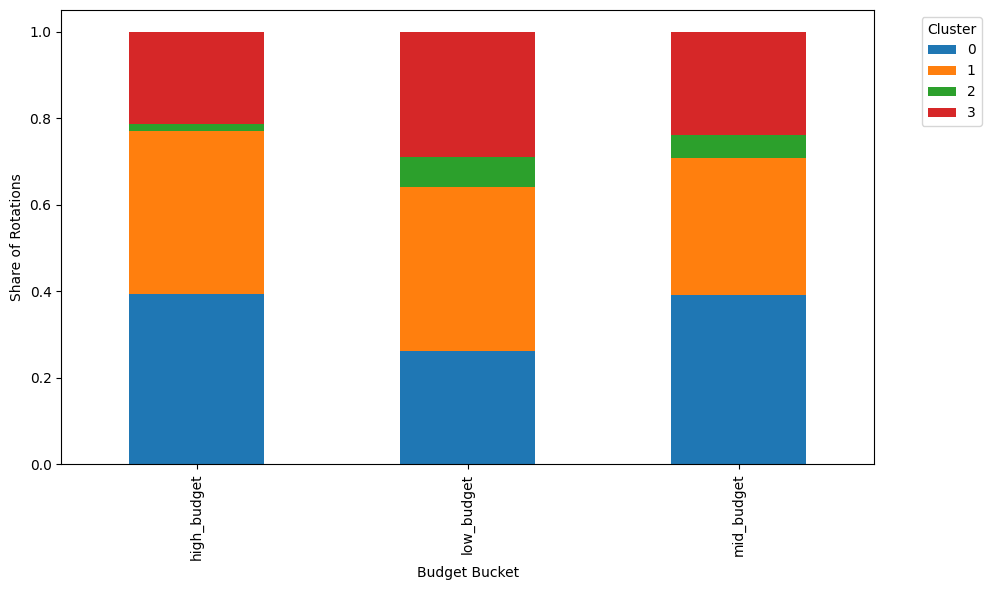

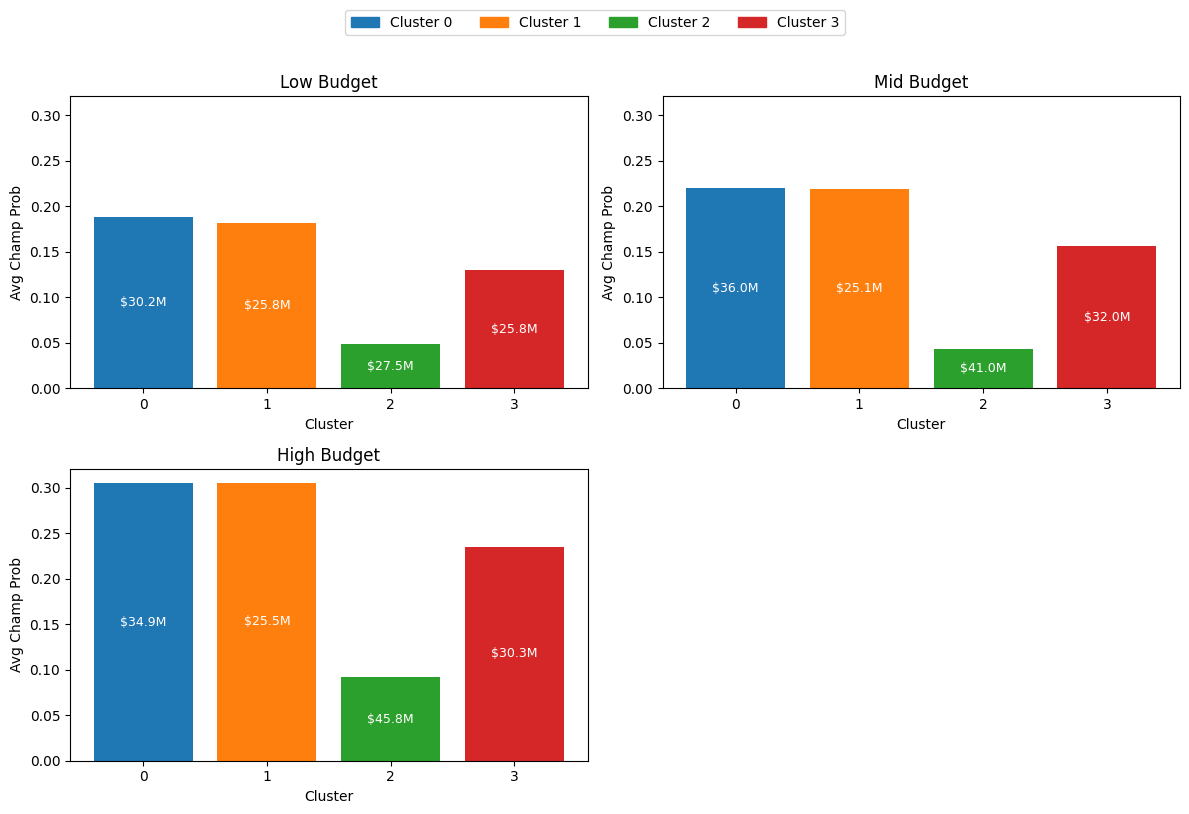

In [73]:
plot_cluster_distribution_by_bucket(pct)
plot_champ_prob_by_bucket_and_cluster(perf)

Across all budget tiers, the top-heavy archetype consistently achieves the highest championship probability, suggesting that concentrating pitching value in elite starters is robustly optimal even when additional payroll flexibility is available.

Top-heavy rotations are more efficient per dollar, allowing more payroll to shift toward offense.

Mid-budget teams tend to build balanced rotations, but should build top-heavy ones. -> In the mid-budget tier, the most frequently observed construction is a balanced rotation; however, a top-heavy configuration yields a higher championship probability. This suggests that teams in this range may be constrained into suboptimal roster structures or that naive optimization favors depth over more effective star concentration.

High-budget teams can afford both strategies, but top-heavy still edges out.


In [59]:
def most_common_pitchers(df, top_n=20):
    """
    Returns the most frequently selected pitchers across all simulations,
    including their WAR and salary.
    """
    counts = (
        df.groupby([
            "name_common", 
            "year_ID", 
            "team_ID",
            "WAR",        # include WAR
            "salary"      # include salary
        ])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    
    return counts.head(top_n)


# usage
top_pitchers = most_common_pitchers(rotation_pitchers, top_n=10)
top_pitchers

,name_common,year_ID,team_ID,WAR,salary,count
0,Aaron Nola,2018,PHI,9.69,573000.0,316
147,Jacob deGrom,2018,NYM,9.44,7400000.0,259
203,Kyle Freeland,2018,COL,7.83,550000.0,206
81,Cristopher Sánchez,2025,PHI,7.97,2000000.0,201
315,Sandy Alcantara,2022,MIA,7.99,3800000.0,178
23,Blake Snell,2018,TBR,7.11,558200.0,166
271,Mike Minor,2019,TEX,7.99,9833333.0,155
212,Lance Lynn,2019,TEX,7.70,9333333.0,131
373,Walker Buehler,2021,LAD,7.13,3750000.0,118
148,Jacob deGrom,2019,NYM,7.18,9000000.0,112


In [14]:
def most_common_pitchers_by_cluster(df, top_n=10):
    """
    Returns most common pitchers within each cluster.
    Requires 'cluster' column.
    """
    
    counts = (
        df.groupby(["cluster", "name_common", "year_ID", "team_ID", "WAR",  
            "salary"])
        .size()
        .reset_index(name="count")
        .sort_values(["cluster", "count"], ascending=[True, False])
    )

    # take top N per cluster
    top = (
        counts.groupby("cluster")
        .head(top_n)
        .reset_index(drop=True)
    )

    return top

# make sure both are aligned
rotation_pitchers = rotation_pitchers.reset_index(drop=True)
rotation_summary = rotation_summary.reset_index(drop=True)

# map cluster to pitcher-level rows
rotation_pitchers["cluster"] = rotation_summary.loc[
    rotation_pitchers.index // 5, "cluster"
].values


In [15]:
# usage
top_by_cluster = most_common_pitchers_by_cluster(rotation_pitchers, top_n=5)
top_by_cluster

,cluster,name_common,year_ID,team_ID,WAR,salary,count
0,0,Cristopher Sánchez,2025,PHI,7.97,2000000.0,103
1,0,Aaron Nola,2018,PHI,9.69,573000.0,101
2,0,Kyle Freeland,2018,COL,7.83,550000.0,99
3,0,Sandy Alcantara,2022,MIA,7.99,3800000.0,92
4,0,Blake Snell,2018,TBR,7.11,558200.0,88
5,1,Aaron Nola,2018,PHI,9.69,573000.0,214
6,1,Jacob deGrom,2018,NYM,9.44,7400000.0,169
7,1,Kyle Freeland,2018,COL,7.83,550000.0,65
8,1,Sandy Alcantara,2022,MIA,7.99,3800000.0,57
9,1,Cristopher Sánchez,2025,PHI,7.97,2000000.0,56


In [60]:
def most_common_pitchers_by_bucket(df, top_n=10):
    counts = (
        df.groupby(["bucket", "name_common", "year_ID", "team_ID", "WAR", "salary"])
        .size()
        .reset_index(name="count")
        .sort_values(["bucket", "count"], ascending=[True, False])
    )

    top = counts.groupby("bucket").head(top_n).reset_index(drop=True)
    return top


# usage
top_by_bucket = most_common_pitchers_by_bucket(rotation_pitchers, top_n=5)
top_by_bucket

,bucket,name_common,year_ID,team_ID,WAR,salary,count
0,high_budget,Aaron Nola,2018,PHI,9.69,573000.0,121
1,high_budget,Jacob deGrom,2018,NYM,9.44,7400000.0,94
2,high_budget,Kyle Freeland,2018,COL,7.83,550000.0,80
3,high_budget,Sandy Alcantara,2022,MIA,7.99,3800000.0,76
4,high_budget,Cristopher Sánchez,2025,PHI,7.97,2000000.0,68
5,low_budget,Aaron Nola,2018,PHI,9.69,573000.0,91
6,low_budget,Jacob deGrom,2018,NYM,9.44,7400000.0,85
7,low_budget,Blake Snell,2018,TBR,7.11,558200.0,71
8,low_budget,Cristopher Sánchez,2025,PHI,7.97,2000000.0,66
9,low_budget,Kyle Freeland,2018,COL,7.83,550000.0,64


In [17]:
def most_common_pitchers_by_bucket_cluster(df, top_n=5):
    counts = (
        df.groupby(["bucket", "cluster", "name_common", "year_ID", "team_ID", "WAR", "salary"])
        .size()
        .reset_index(name="count")
        .sort_values(["bucket", "cluster", "count"], ascending=[True, True, False])
    )

    top = (
        counts.groupby(["bucket", "cluster"])
        .head(top_n)
        .reset_index(drop=True)
    )

    return top


# usage
top_bc = most_common_pitchers_by_bucket_cluster(rotation_pitchers, top_n=5)
top_bc

,bucket,cluster,name_common,year_ID,team_ID,WAR,salary,count
0,high_budget,0,Cristopher Sánchez,2025,PHI,7.97,2000000.0,41
1,high_budget,0,Kyle Freeland,2018,COL,7.83,550000.0,41
2,high_budget,0,Aaron Nola,2018,PHI,9.69,573000.0,39
3,high_budget,0,Sandy Alcantara,2022,MIA,7.99,3800000.0,37
4,high_budget,0,Mike Minor,2019,TEX,7.99,9833333.0,33
5,high_budget,1,Aaron Nola,2018,PHI,9.69,573000.0,82
6,high_budget,1,Jacob deGrom,2018,NYM,9.44,7400000.0,61
7,high_budget,1,Kyle Freeland,2018,COL,7.83,550000.0,24
8,high_budget,1,Sandy Alcantara,2022,MIA,7.99,3800000.0,24
9,high_budget,1,Walker Buehler,2021,LAD,7.13,3750000.0,19
